In [43]:
from vmc_ising import (
    output_dir,
    get_config,
    get_lattice,
    default_config,
    get_network,
    get_system,
    reconstruct_signs,
    find_sign_overlap,
)
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd

In [32]:
def get_energy(signs, system, log_prob_fn):
    probs = safe_exp(
        (log_prob_fn(torch.from_numpy(system.basis.states.astype(np.int64))) / 2),
        normalise=True,
    ).view(-1).detach().numpy()
    
    amplitudes = np.sqrt(probs)
    wavefunction = signs * amplitudes
    return (system.hamiltonian @ wavefunction) @ wavefunction


In [3]:
df = read_jsonl_to_df(output_dir.glob("*/results.jsonl")).fillna(
    keep_serializable(default_config)
)

In [22]:
task_id = 25
config = get_config(task_id)
system = get_system(config)
system.get_eigenstates(1)
log_prob_fn = get_network(config, get_system(config))

2024-03-07 15:29:42.248 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=18
2024-03-07 15:29:42.249 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-03-07 15:29:42.249 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-03-07 15:29:42.250 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-03-07 15:29:42.269 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 48620
2024-03-07 15:29:42.274 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-False-None-1.pickle
2024-03-07 15:29:42.275 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -32.1930830942
2024-03-07 15:29:42.281 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=18
2024-03-07 15:29:42.282 | DEBUG    | heisenberg_hamilto

In [37]:
df.columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps', 'config_warm_up.sign_noise',
       'config_log_prob_fn', 'config_kernel_size', 'amplitude_overlap',
       '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'start_timestamp',
       'task_id', 'device', 'warm_up', 'sign_overlap', 'step_since_warm_up',
       'signs_updated', 'signs_updated_at', 'step_since_signs_updated',
       'config_sign_reconstruction.repetitions', 'overlap',
       'config_checkpoint_log_prob_fn_each'],
      dtype='object')

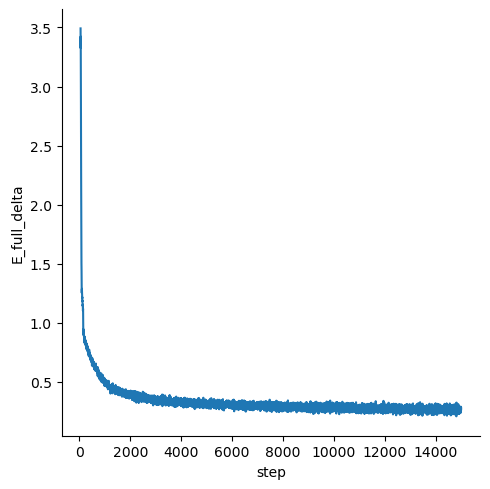

In [41]:
sns.relplot(df.query(f"task_id == {task_id} and not warm_up"), x="step", y="E_full_delta", kind="line")

In [26]:
step = 10100
true_signs = np.sign(system.get_ground_state())


<All keys matched successfully>

In [50]:
reconstructed_signs_list = []
for step in range(0, 15000, 100):
    log_prob_fn.load_state_dict(
        torch.load(
            output_dir / f"{task_id}/log_prob_fn_{step}.pt",
            map_location=torch.device("cpu"),
        )
    )
    reconstructed_signs_list.append(
        reconstruct_signs(
            system,
            log_prob_fn,
            number_sweeps=config["sign_reconstruction.number_sweeps"],
            how=config["sign_reconstruction.method"],
            repetitions=config["sign_reconstruction.repetitions"],
        )
    )

In [51]:
reconstructed_signs_list = reconstructed_signs

In [47]:
ising_energy = []
previous_reconstructed_signs = None
for step, reconstructed_signs in zip(range(0, 15000, 100), reconstructed_signs_list):
    log_prob_fn.load_state_dict(
        torch.load(
            output_dir / f"{task_id}/log_prob_fn_{step}.pt",
            map_location=torch.device("cpu"),
        )
    )
    if previous_reconstructed_signs is not None:
        sign_overlap_incremental = (
            reconstructed_signs
            * previous_reconstructed_signs
            * system.get_ground_state() ** 2
        ).sum()
    else:
        sign_overlap_incremental = None
    sign_overlap_with_true = find_sign_overlap(system, reconstructed_signs)
    
    previous_reconstructed_signs = reconstructed_signs
    ising_energy.append(
        dict(
            ising_energy_reconstructed_signs=get_energy(
                reconstructed_signs, system, log_prob_fn
            ),
            ising_energy_true_signs=get_energy(true_signs, system, log_prob_fn),
            step=step,
            sign_overlap_incremental=sign_overlap_incremental,
        )
    )
    # system.hamiltonian @ wavefunction

<Axes: xlabel='step'>

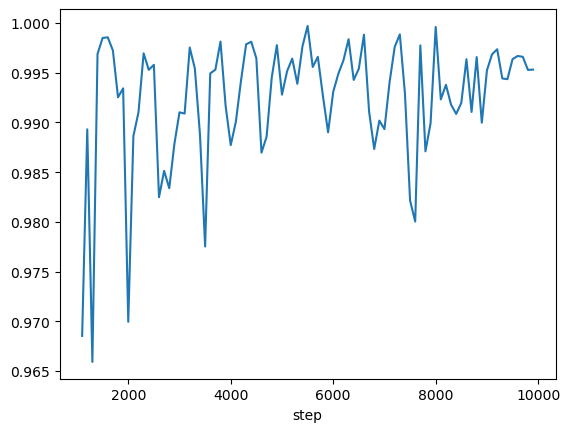

In [49]:
pd.DataFrame(ising_energy).assign(
    delta=lambda df: df["ising_energy_reconstructed_signs"]
    - df["ising_energy_true_signs"],
    sign_overlap_incremental=lambda df: df["sign_overlap_incremental"].abs(),
).set_index("step")["sign_overlap_incremental"].plot()